# GameTheory 16g - Arrow : Preuve Formelle et Simulation

**Navigation** : [<< 16b-Lean-SocialChoice](GameTheory-16b-Lean-SocialChoice.ipynb) | [16c-SocialChoice-Python >>](GameTheory-16c-SocialChoice-Python.ipynb) | [Index](README.md)

**Autres notebooks de la serie** : [16d-SAT](GameTheory-16d-SocialChoice-SAT.ipynb) | [16e-Tour](GameTheory-16e-SocialChoiceLean-Tour.ipynb) | [16f-Z3](GameTheory-16f-SocialChoice-Z3.ipynb)

**Kernel** : Python 3

---

## Introduction

Ce notebook est un **tutoriel transversal** qui relie deux approches complementaires du theoreme d'impossibilite d'Arrow :

| Notebook | Approche | Ce qu'il montre |
|----------|----------|------------------|
| **16b (Lean)** | Preuve formelle | Le theoreme est vrai pour TOUS les profils possibles |
| **16c (Python)** | Simulation empirique | Les regles usuelles violent les axiomes dans la pratique |
| **Ce notebook (16g)** | Pont formel/empirique | Chaque etape de la preuve illustree en Python |

### Idee cle

La preuve formelle en Lean garantit l'impossibilite pour un nombre **infini** de profils. La simulation Python ne teste qu'un nombre **fini** de cas. Ce notebook montre pourquoi cette difference est fondamentale.

### Objectifs d'apprentissage

1. Comprendre chaque axiome d'Arrow a travers sa definition Lean et son test Python
2. Suivre la structure de la preuve de Geanakoplos (2005) etape par etape
3. Comprendre la limite fondamentale entre preuve formelle et simulation

### Prerequis

- Notions de base sur les relations de preference (notebook 16c)
- Notion de theoreme d'impossibilite (notebook 16b ou 16c)

### Duree estimee : 45 minutes

In [1]:
# Section 0 : Configuration
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from collections import Counter, defaultdict
import random

random.seed(42)
np.random.seed(42)

print("Configuration OK : Arrow CrossSeries 16g")

Configuration OK : Arrow CrossSeries 16g


---

## 1. Les Trois Axiomes d'Arrow

Le theoreme d'Arrow repose sur trois axiomes que l'on pourrait considerer comme "raisonnables" pour un systeme de vote equitable. Pour chaque axiome, nous presentons :
- La **definition formelle en Lean** (issue de `social_choice_lean/SocialChoice/Framework.lean`)
- Un **test Python** qui verifie si une regle de vote satisfait cet axiome

### Definitions de base (rappel Lean)

Dans le formalisme Lean du projet `social_choice_lean` :

```lean
-- Fonction de bien-etre social
def SWF (i sigma : Type*) := Profile i sigma -> PrefOrder sigma

-- Relation de preference stricte
def P (R : sigma -> sigma -> Prop) (x y : sigma) : Prop :=
  R x y /\ ¬R y x
```

### 1.1 Pareto Faible (Unanimite)

**Definition Lean** (Framework.lean) :
```lean
def weak_pareto (f : SWF i sigma) (X : Finset sigma) : Prop :=
  forall prof : Profile i sigma, forall x y : sigma, x \in X -> y \in X ->
    (forall i : iota, P (prof i).rel x y) -> P (f prof).rel x y
```

**En francais** : Si **tous** les individus preferent strictement x a y, alors la societe prefere aussi strictement x a y.

**Intuition** : C'est la condition la plus naturelle -- l'unanimite devrait se refléter dans le choix collectif.

In [2]:
# 1.1 Pareto Faible -- Test Python

def borda_rule(profile):
    """Regle de Borda : points selon le rang."""
    scores = defaultdict(int)
    n = len(profile[0])
    for pref in profile:
        for rank, alt in enumerate(pref):
            scores[alt] += (n - 1 - rank)
    return sorted(scores.keys(), key=lambda x: -scores[x])


def plurality_rule(profile):
    """Regle de la pluralite : l'alternative avec le plus de premiers choix gagne."""
    first_choices = [p[0] for p in profile]
    counts = Counter(first_choices)
    alternatives = list(dict.fromkeys(x for p in profile for x in p))
    return sorted(alternatives, key=lambda x: -counts.get(x, 0))


def dictatorial_rule(profile, dictator_idx=0):
    """Regle dictatoriale : le classement social = preference du dictateur."""
    return list(profile[dictator_idx])


def check_weak_pareto(voting_rule, n_voters, alternatives, n_tests=500):
    """Teste si une regle de vote satisfait Pareto faible.

    Pour chaque profil teste, verifie que si tous les votants
    preferent x a y, alors le classement social a aussi x avant y.

    Args:
        voting_rule: fonction prenant un profil (list de listes)
                     et retournant un classement (list)
        n_voters: nombre de votants
        alternatives: liste des alternatives
        n_tests: nombre de profils a tester

    Returns:
        int: nombre de violations detectees
    """
    violations = 0
    for _ in range(n_tests):
        profile = []
        for _ in range(n_voters):
            p = list(alternatives)
            random.shuffle(p)
            profile.append(p)

        ranking = voting_rule(profile)

        # Tester toutes les paires (x, y) ou tous preferent x a y
        for x, y in combinations(alternatives, 2):
            all_prefer = all(
                pref.index(x) < pref.index(y) for pref in profile
            )
            if all_prefer:
                if ranking.index(x) > ranking.index(y):
                    violations += 1

    return violations


# Test sur differentes regles
alternatives = ['A', 'B', 'C']
n_voters = 5

print("TEST DU AXIOME DE PARETO FAIBLE")
print("=" * 33)

for name, rule in [
    ("Regle de Borda", borda_rule),
    ("Dictature (electeur 0)", lambda p: dictatorial_rule(p, 0)),
    ("Pluralite", plurality_rule),
]:
    v = check_weak_pareto(rule, n_voters, alternatives)
    status = "SATISFAIT Pareto faible" if v == 0 else f"VIOLE ({v} cas)"
    print(f"{name} :")
    print(f"  Teste sur 500 profils aleatoires... {v} violations")
    print(f"  => {status}\n")

TEST DU AXIOME DE PARETO FAIBLE
Regle de Borda :
  Teste sur 500 profils aleatoires... 0 violations
  => SATISFAIT Pareto faible

Dictature (electeur 0) :
  Teste sur 500 profils aleatoires... 0 violations
  => SATISFAIT Pareto faible

Pluralite :
  Teste sur 500 profils aleatoires... 0 violations
  => SATISFAIT Pareto faible



### Interpretation : Pareto Faible

**Resultat** : les trois regles testees satisfont toutes Pareto faible.

| Regle | Violations (sur 500 tests) | Verdict |
|-------|---------------------------|----------|
| Borda | 0 | Satisfait |
| Dictature | 0 | Satisfait |
| Pluralite | 0 | Satisfait |

**Point cle** : meme une dictature satisfait Pareto faible ! Si le dictateur prefere x a y (et tout le monde aussi par hypothese), le classement social suit le dictateur.

> **Note** : Pareto faible est le plus "facile" a satisfaire des trois axiomes. La ou les choses se compliquent, c'est quand on exige aussi l'IIA et la non-dictature.

### 1.2 Independance des Alternatives Non-Pertinentes (IIA)

**Definition Lean** (Framework.lean) :
```lean
def ind_of_irr_alts (f : SWF i sigma) (X : Finset sigma) : Prop :=
  forall prof prof' : Profile i sigma, forall x y : sigma,
    x \in X -> y \in X ->
    (forall i : iota, same_order' (prof i).rel (prof' i).rel x y x y) ->
    same_order' (f prof).rel (f prof').rel x y x y
```

**En francais** : Le classement social entre x et y depend **uniquement** des preferences individuelles entre x et y. Changer le classement d'une autre alternative ne doit pas affecter x vs y.

**Intuition** : Si un electeur change d'avis sur le classement A vs C, cela ne devrait pas changer le classement social de A vs B.

In [3]:
# 1.2 IIA -- Test Python

def check_iia(voting_rule, n_voters, alternatives, n_tests=1000):
    """Teste si une regle de vote satisfait IIA.

    Pour chaque paire de profils (prof, prof') ou les preferences
    individuelles entre x et y sont identiques pour chaque votant,
    verifie que le classement social relatif de x vs y ne change pas.

    Args:
        voting_rule: fonction prenant un profil et retournant un classement
        n_voters: nombre de votants
        alternatives: liste des alternatives
        n_tests: nombre de paires de profils a tester

    Returns:
        int: nombre de violations detectees
    """
    violations = 0
    alts = list(alternatives)

    for _ in range(n_tests):
        # Generer deux profils aleatoires
        profile1 = []
        profile2 = []
        for _ in range(n_voters):
            p1 = list(alts)
            random.shuffle(p1)
            p2 = list(alts)
            random.shuffle(p2)
            profile1.append(p1)
            profile2.append(p2)

        # Choisir une paire (x, y) au hasard
        x, y = random.sample(alts, 2)

        # Verifier que les preferences individuelles entre x et y
        # sont les memes dans les deux profils
        same_xy = all(
            (p1.index(x) < p1.index(y)) == (p2.index(x) < p2.index(y))
            for p1, p2 in zip(profile1, profile2)
        )
        if not same_xy:
            continue

        # Comparer le classement social relatif de x vs y
        ranking1 = voting_rule(profile1)
        ranking2 = voting_rule(profile2)

        xy_in_1 = ranking1.index(x) < ranking1.index(y)
        xy_in_2 = ranking2.index(x) < ranking2.index(y)

        if xy_in_1 != xy_in_2:
            violations += 1

    return violations


# Test sur differentes regles
print("TEST DE L'AXIOME IIA (Independance des Alternatives Non-Pertinentes)")
print("=" * 69)

for name, rule in [
    ("Regle de Borda", borda_rule),
    ("Pluralite", plurality_rule),
    ("Dictature (electeur 0)", lambda p: dictatorial_rule(p, 0)),
]:
    v = check_iia(rule, n_voters, alternatives)
    status = "SATISFAIT IIA" if v == 0 else f"VIOLE IIA ({v} violations)"
    print(f"{name} :")
    print(f"  Teste sur 1000 paires de profils... {v} violations")
    print(f"  => {status}\n")

TEST DE L'AXIOME IIA (Independance des Alternatives Non-Pertinentes)
Regle de Borda :
  Teste sur 1000 paires de profils... 2 violations
  => VIOLE IIA (2 violations)



Pluralite :
  Teste sur 1000 paires de profils... 7 violations
  => VIOLE IIA (7 violations)

Dictature (electeur 0) :
  Teste sur 1000 paires de profils... 0 violations
  => SATISFAIT IIA



### Interpretation : IIA

**Resultat** : seul le dictateur satisfait IIA !

| Regle | Violations IIA | Verdict |
|-------|----------------|----------|
| Borda | eleve | Viole IIA |
| Pluralite | eleve | Viole IIA |
| Dictature | 0 | Satisfait IIA |

**Pourquoi Borda viole IIA** : les scores de Borda dependent de la position de **toutes** les alternatives, pas seulement de x et y. Ajouter ou retirer une alternative peut changer le classement relatif de x vs y.

**Pourquoi la dictature satisfait IIA** : le classement social = celui du dictateur, donc le classement relatif x vs y ne depend que de la preference du dictateur sur x vs y, independamment des autres alternatives.

> **Premier indice du theoreme d'Arrow** : les regles "raisonnables" (Borda, Pluralite) violent IIA, et seule la dictature le satisfait...

### 1.3 Non-dictature

**Definition Lean** (Arrow.lean) :
```lean
def is_dictatorship (f : SWF i sigma) (X : Finset sigma) : Prop :=
  exists d : iota,
    forall x y : sigma, x \in X -> y \in X -> x ≠ y ->
      is_dictator_on f d x y

def non_dictatorial (f : SWF i sigma) (X : Finset sigma) : Prop :=
  not (is_dictatorship f X)
```

**En francais** : Il n'existe **aucun** individu dont la preference stricte est toujours suivie par le classement social.

**Intuition** : Aucun electeur ne devrait avoir un pouvoir de veto absolu sur le classement social.

In [4]:
# 1.3 Non-dictature -- Test Python

def check_non_dictatorship(voting_rule, n_voters, alternatives, n_tests=500):
    """Teste si une regle de vote est dictatoriale.

    Pour chaque votant, verifie si sa preference stricte
    est toujours suivie par le classement social.

    Args:
        voting_rule: fonction prenant un profil et retournant un classement
        n_voters: nombre de votants
        alternatives: liste des alternatives
        n_tests: nombre de profils a tester

    Returns:
        int or None: index du dictateur si trouve, None sinon
    """
    for d in range(n_voters):
        is_dict = True
        for _ in range(n_tests):
            profile = []
            for _ in range(n_voters):
                p = list(alternatives)
                random.shuffle(p)
                profile.append(p)

            ranking = voting_rule(profile)

            # Verifier : pour TOUTE paire, si le dictateur prefere x a y,
            # le classement social doit avoir x avant y
            for x, y in combinations(alternatives, 2):
                # Le dictateur prefere strictement x a y
                if profile[d].index(x) < profile[d].index(y):
                    if ranking.index(x) > ranking.index(y):
                        is_dict = False
                        break
                # Le dictateur prefere strictement y a x
                elif profile[d].index(y) < profile[d].index(x):
                    if ranking.index(y) > ranking.index(x):
                        is_dict = False
                        break
            if not is_dict:
                break
        if is_dict:
            return d
    return None


print("TEST DE NON-DICTATURE")
print("=" * 22)

for name, rule in [
    ("Regle de Borda", borda_rule),
    ("Pluralite", plurality_rule),
    ("Dictature (electeur 0)", lambda p: dictatorial_rule(p, 0)),
]:
    d = check_non_dictatorship(rule, n_voters, alternatives)
    if d is not None:
        print(f"{name} :")
        print(f"  Teste sur 500 profils... DICTATURE (dictateur = electeur {d})\n")
    else:
        print(f"{name} :")
        print(f"  Teste sur 500 profils... non-dictatoriale\n")

TEST DE NON-DICTATURE
Regle de Borda :
  Teste sur 500 profils... non-dictatoriale

Pluralite :
  Teste sur 500 profils... non-dictatoriale

Dictature (electeur 0) :
  Teste sur 500 profils... DICTATURE (dictateur = electeur 0)



### Bilan des trois axiomes

| Regle | Pareto | IIA | Non-dictature | Les trois ? |
|-------|--------|-----|---------------|-------------|
| Borda | Oui | **Non** | Oui | **Non** |
| Pluralite | Oui | **Non** | Oui | **Non** |
| Dictature | Oui | Oui | **Non** | **Non** |

**Observation** : aucune regle ne parvient a satisfaire les trois axiomes simultanement. C'est exactement ce que dit le theoreme d'Arrow -- et la preuve formelle en Lean montre que ce n'est pas un artefact de nos tests, mais une verite mathematique.

---

## 2. La Preuve en 4 Etapes (Geanakoplos 2005)

La preuve formelle dans `social_choice_lean/SocialChoice/Arrow.lean` suit la structure de la preuve de Geanakoplos (2005). Elle procede en **quatre etapes** que nous allons illustrer :

1. **Lemme Extremal** : si tout le monde place b en position extreme, la societe aussi
2. **Existence du Pivot** : il existe un individu qui peut faire basculer b du bas au sommet
3. **Le Pivot est un Dictateur (sauf pour b)** : le pivot dicte le classement de toutes les paires ne contenant pas b
4. **Le Theoreme Final** : le pivot est un dictateur complet

### 2.1 Lemme Extremal

**Definition Lean** (Arrow.lean, ligne 199) :
```lean
theorem extremal_lemma (f : SWF i sigma) (X : Finset sigma)
    (hwp : weak_pareto f X) (hind : ind_of_irr_alts f X)
    (hX : 3 <= X.card) (b : sigma) (hb : b \in X)
    (prof : Profile i sigma)
    (hall : forall i : iota, is_extremal (prof i).rel b X) :
    is_extremal (f prof).rel b X
```

**En francais** : Si chaque individu place l'alternative b soit en **premiere** position, soit en **derniere** position (et nulle part entre les deux), alors le classement social place aussi b en position extreme.

**Preuve (idee)** : Par l'absurde. Si la societe ne place pas b en position extreme, alors il existe a et c tels que la societe prefere a > b > c. Mais par IIA, le classement entre a et b (ou b et c) ne depend que des preferences individuelles sur ces paires. Comme b est toujours extreme pour chaque individu, les preferences sur (a,b) et (b,c) sont liees -- ce qui mene a une contradiction avec Pareto.

In [5]:
# 2.1 Lemme Extremal -- Simulation Python

def generate_extremal_profiles(n_voters, alternatives, target):
    """Genere des profils ou 'target' est toujours en premiere ou derniere position.

    Args:
        n_voters: nombre de votants
        alternatives: liste des alternatives
        target: l'alternative a placer en position extreme

    Returns:
        list: profil genere
    """
    profile = []
    others = [a for a in alternatives if a != target]
    for _ in range(n_voters):
        random.shuffle(others)
        if random.random() < 0.5:
            # target en premier
            profile.append([target] + list(others))
        else:
            # target en dernier
            profile.append(list(others) + [target])
    return profile


def is_extreme_position(ranking, item, n):
    """Verifie si 'item' est en premiere ou derniere position."""
    idx = ranking.index(item)
    return idx == 0 or idx == n - 1


alternatives_3 = ['A', 'B', 'C']
n_voters_test = 5
target = 'B'

print("LEMME EXTREMAL : SIMULATION")
print("=" * 28)
print(f"Alternatives : {alternatives_3}")
print(f"{target} sera place en position extreme (premier ou dernier)"
      f" par chaque electeur")

# Cas 1 : tous placent B en dernier
print(f"\nProfil 1 : tous placent {target} en dernier")
profile_bottom = []
others = ['A', 'C']
for _ in range(n_voters_test):
    p = list(others)
    random.shuffle(p)
    profile_bottom.append(p + [target])

for i, pref in enumerate(profile_bottom):
    pos = "PREMIER" if pref.index(target) == 0 else "DERNIER"
    print(f"  Electeur {i}: {pref}  -> {target} est {pos}")

ranking = borda_rule(profile_bottom)
pos_b = "PREMIER" if ranking.index(target) == 0 else "DERNIER"
print(f"  Classement Borda : {ranking}")
print(f"  Position de {target} : {pos_b} (index {ranking.index(target)})")
extreme = is_extreme_position(ranking, target, len(alternatives_3))
print(f"  => {target} est {'bien' if extreme else 'PAS'} en position EXTREME")

# Cas 2 : tous placent B en premier
print(f"\nProfil 2 : tous placent {target} en premier")
profile_top = []
for _ in range(n_voters_test):
    p = list(others)
    random.shuffle(p)
    profile_top.append([target] + p)

for i, pref in enumerate(profile_top):
    pos = "PREMIER" if pref.index(target) == 0 else "DERNIER"
    print(f"  Electeur {i}: {pref}  -> {target} est {pos}")

ranking = borda_rule(profile_top)
pos_b = "PREMIER" if ranking.index(target) == 0 else "DERNIER"
print(f"  Classement Borda : {ranking}")
print(f"  Position de {target} : {pos_b} (index {ranking.index(target)})")
extreme = is_extreme_position(ranking, target, len(alternatives_3))
print(f"  => {target} est {'bien' if extreme else 'PAS'} en position EXTREME")

# Cas 3 : mixte
print(f"\nProfil 3 : positions mixtes ({target} premier ou dernier)")
profile_mix = generate_extremal_profiles(n_voters_test, alternatives_3, target)
for i, pref in enumerate(profile_mix):
    pos = "PREMIER" if pref.index(target) == 0 else "DERNIER"
    print(f"  Electeur {i}: {pref}  -> {target} est {pos}")

ranking = borda_rule(profile_mix)
pos_b = "PREMIER" if ranking.index(target) == 0 else "DERNIER"
print(f"  Classement Borda : {ranking}")
print(f"  Position de {target} : {pos_b} (index {ranking.index(target)})")
extreme = is_extreme_position(ranking, target, len(alternatives_3))
print(f"  => {target} est {'bien' if extreme else 'PAS'} en position EXTREME")

# Test systematique
n_extreme = 0
n_total = 100
for _ in range(n_total):
    prof = generate_extremal_profiles(n_voters_test, alternatives_3, target)
    r = borda_rule(prof)
    if is_extreme_position(r, target, len(alternatives_3)):
        n_extreme += 1

print(f"\nResume sur {n_total} profils aleatoires :")
print(f"  {target} toujours en position extreme (social) : {n_extreme}/{n_total}")

LEMME EXTREMAL : SIMULATION
Alternatives : ['A', 'B', 'C']
B sera place en position extreme (premier ou dernier) par chaque electeur

Profil 1 : tous placent B en dernier
  Electeur 0: ['A', 'C', 'B']  -> B est DERNIER
  Electeur 1: ['A', 'C', 'B']  -> B est DERNIER
  Electeur 2: ['C', 'A', 'B']  -> B est DERNIER
  Electeur 3: ['A', 'C', 'B']  -> B est DERNIER
  Electeur 4: ['C', 'A', 'B']  -> B est DERNIER
  Classement Borda : ['A', 'C', 'B']
  Position de B : DERNIER (index 2)
  => B est bien en position EXTREME

Profil 2 : tous placent B en premier
  Electeur 0: ['B', 'C', 'A']  -> B est PREMIER
  Electeur 1: ['B', 'C', 'A']  -> B est PREMIER
  Electeur 2: ['B', 'A', 'C']  -> B est PREMIER
  Electeur 3: ['B', 'A', 'C']  -> B est PREMIER
  Electeur 4: ['B', 'C', 'A']  -> B est PREMIER
  Classement Borda : ['B', 'C', 'A']
  Position de B : PREMIER (index 0)
  => B est bien en position EXTREME

Profil 3 : positions mixtes (B premier ou dernier)
  Electeur 0: ['B', 'C', 'A']  -> B est P

### 2.2 Existence du Pivot

**Definition Lean** (Arrow.lean, ligne 279) :
```lean
theorem pivot_exists (f : SWF i sigma) (X : Finset sigma)
    (hwp : weak_pareto f X) (hind : ind_of_irr_alts f X)
    (hX : 3 <= X.card) (b : sigma) (hb : b \in X) :
    exists n : iota, is_pivotal f X n b
```

**En francais** : Pour toute alternative b, il existe un individu "pivotal" -- c'est-a-dire un electeur dont le changement de preference peut faire passer b du **bas** au **sommet** du classement social.

**Preuve (idee)** : On construit une sequence de profils $prof^0, prof^1, ..., prof^m$ ou progressivement chaque electeur passe b du bas au sommet. Par le lemme extremal, b est toujours en position extreme socialement. Au depart ($prof^0$), b est en bas (Pareto). A la fin ($prof^m$), b est en haut (Pareto). Il y a donc un moment ou un seul electeur fait basculer b -- c'est le pivot.

In [6]:
# 2.2 Existence du Pivot -- Simulation Python

def find_pivot_sequence(voting_rule, n_voters, alternatives, target):
    """Trouve l'electeur pivot en faisant basculer 'target' du bas au sommet.

    Args:
        voting_rule: regle de vote
        n_voters: nombre de votants
        alternatives: liste des alternatives
        target: alternative cible

    Returns:
        int or None: index de l'electeur pivot
    """
    others = [a for a in alternatives if a != target]

    # Etat initial : tous placent target en bas
    profile = []
    for _ in range(n_voters):
        p = list(others)
        random.shuffle(p)
        profile.append(p + [target])

    ranking = voting_rule(profile)
    was_last = ranking.index(target) == len(alternatives) - 1

    if not was_last:
        return None  # target n'est pas dernier, conditions non remplies

    # Progressivement, chaque electeur passe target en haut
    for step in range(n_voters):
        others_copy = list(others)
        random.shuffle(others_copy)
        profile[step] = [target] + others_copy

        ranking = voting_rule(profile)
        is_first = ranking.index(target) == 0

        if is_first:
            return step  # L'electeur 'step' est le pivot

    return None  # Pas de basculement trouve (ne devrait pas arriver)


alternatives_3 = ['A', 'B', 'C']
n_voters_test = 5
target = 'B'

print("EXISTENCE DU PIVOT : SIMULATION")
print("=" * 32)
print(f"Alternatives : {alternatives_3} | {n_voters_test} electeurs")
print(f"Cible : {target}")

# Demonstration detaillee
print(f"\nSequence de profils ({target} passe du bas vers le haut):")
print("-" * 65)

others = ['A', 'C']
profile = []
random.seed(10)  # Pour une demonstration reproductible
for _ in range(n_voters_test):
    p = list(others)
    random.shuffle(p)
    profile.append(p + [target])

# Etat initial
ranking = borda_rule(profile)
scores = defaultdict(int)
n = len(alternatives_3)
for pref in profile:
    for rank, alt in enumerate(pref):
        scores[alt] += (n - 1 - rank)

pos_b = "PREMIER" if ranking.index(target) == 0 else "DERNIER"
print(f"Etape 0: {target} est en bas pour tous")
for i in range(n_voters_test):
    pref_str = ' > '.join(profile[i])
    if i < 3:
        print(f"  Electeur {i}: {pref_str}", end=" | ")
    elif i == 3:
        print(f"Electeur {i}: {pref_str}")
        pref_str = ' > '.join(profile[i])
        print(f"  Electeur {i}: {pref_str}")
    else:
        print(f"  Electeur {i}: {pref_str}")

# Reformater l'affichage des electeurs
print()  # Reset
random.seed(10)  # Reset pour la meme sequence
profile = []
for _ in range(n_voters_test):
    p = list(others)
    random.shuffle(p)
    profile.append(p + [target])

pivot_found = None
for step in range(n_voters_test):
    ranking = borda_rule(profile)
    scores = defaultdict(int)
    n = len(alternatives_3)
    for pref in profile:
        for rank, alt in enumerate(pref):
            scores[alt] += (n - 1 - rank)

    pos_b = "PREMIER" if ranking.index(target) == 0 else "DERNIER"
    if step == 0:
        label = f"Etape {step}: {target} est en bas pour tous"
    else:
        label = f"Etape {step}: Electeur {step-1} passe {target} en haut"
    print(label)
    for i in range(n_voters_test):
        pref_str = ' > '.join(profile[i])
        print(f"  Electeur {i}: {pref_str}")
    print(f"  Social (Borda): {ranking} -> {target} est {pos_b}")
    print(f"  Score {target}: {scores[target]} | "
          f"Score A: {scores['A']} | Score C: {scores['C']}")

    if ranking.index(target) == 0 and pivot_found is None:
        pivot_found = step - 1 if step > 0 else None
        if pivot_found is not None:
            print(f"\n** BASCULEMENT : {target} passe du bas au sommet "
                  f"quand l'electeur {pivot_found} change **")
            print(f"L'electeur {pivot_found} est le PIVOT pour cette execution.")
            break
    print()

    # Passer l'electeur suivant
    if step < n_voters_test:
        others_copy = list(others)
        random.shuffle(others_copy)
        profile[step] = [target] + others_copy

# Statistiques sur plusieurs repetitions
random.seed(42)
pivot_counts = Counter()
n_trials = 100
for _ in range(n_trials):
    p = find_pivot_sequence(borda_rule, n_voters_test, alternatives_3, target)
    if p is not None:
        pivot_counts[p] += 1

print(f"\nResume sur {n_trials} repetitions :")
most_common = pivot_counts.most_common(1)
if most_common:
    pivot_id, count = most_common[0]
    print(f"  Pivot le plus frequent : electeur {pivot_id} "
          f"({count} occurrences)")
print(f"  Distribution des pivots : {dict(pivot_counts)}")

EXISTENCE DU PIVOT : SIMULATION
Alternatives : ['A', 'B', 'C'] | 5 electeurs
Cible : B

Sequence de profils (B passe du bas vers le haut):
-----------------------------------------------------------------
Etape 0: B est en bas pour tous
  Electeur 0: C > A > B |   Electeur 1: A > C > B |   Electeur 2: A > C > B | Electeur 3: C > A > B
  Electeur 3: C > A > B
  Electeur 4: C > A > B

Etape 0: B est en bas pour tous
  Electeur 0: C > A > B
  Electeur 1: A > C > B
  Electeur 2: A > C > B
  Electeur 3: C > A > B
  Electeur 4: C > A > B
  Social (Borda): ['C', 'A', 'B'] -> B est DERNIER
  Score B: 0 | Score A: 7 | Score C: 8

Etape 1: Electeur 0 passe B en haut
  Electeur 0: B > A > C
  Electeur 1: A > C > B
  Electeur 2: A > C > B
  Electeur 3: C > A > B
  Electeur 4: C > A > B
  Social (Borda): ['A', 'C', 'B'] -> B est DERNIER
  Score B: 2 | Score A: 7 | Score C: 6

Etape 2: Electeur 1 passe B en haut
  Electeur 0: B > A > C
  Electeur 1: B > A > C
  Electeur 2: A > C > B
  Electeur 3: C 

### 2.3 Le Pivot est un Dictateur (sauf pour b)

**Definition Lean** (Arrow.lean, ligne 408) :
```lean
theorem pivot_is_dictator_except_b (f : SWF i sigma) (X : Finset sigma)
    (hind : ind_of_irr_alts f X)
    (b : sigma) (hb : b \in X)
    (n : iota) (hn : is_pivotal f X n b)
    (a c : sigma) (ha : a \in X) (hc : c \in X)
    (hab : a ≠ b) (hcb : c ≠ b) (hac : a ≠ c) :
    is_dictator_on f n c a
```

**En francais** : L'electeur pivotal pour b est un **dictateur partiel** : pour toute paire (a, c) qui ne contient PAS b, le pivot dicte le classement social. Si le pivot prefere c a a, la societe prefere c a a.

**Preuve (idee)** : On construit des profils auxiliaires ou b est utilise comme "leurre". Par IIA, le classement entre a et c ne depend que des preferences individuelles sur (a, c). En manipulant la position de b, on utilise le fait que le pivot peut controler le classement de b pour deduire qu'il controle aussi (a, c).

In [7]:
# 2.3 Pivot = Dictateur partiel -- Simulation Python

def check_partial_dictator(voting_rule, n_voters, alternatives,
                           pivot_idx, target, pair_without_target,
                           n_tests=500):
    """Teste si le pivot dicte le classement pour une paire ne contenant
    pas l'alternative cible.

    Args:
        voting_rule: regle de vote
        n_voters: nombre de votants
        alternatives: liste des alternatives
        pivot_idx: index du pivot suppose
        target: alternative cible (b dans la preuve)
        pair_without_target: tuple (a, c) ne contenant pas target
        n_tests: nombre de tests

    Returns:
        int: nombre de fois ou le pivot ne dicte PAS le classement
    """
    a, c = pair_without_target
    non_concordances = 0

    for _ in range(n_tests):
        profile = []
        for _ in range(n_voters):
            p = list(alternatives)
            random.shuffle(p)
            profile.append(p)

        ranking = voting_rule(profile)

        # Le pivot prefere a a c ?
        pivot_prefers_a = profile[pivot_idx].index(a) < profile[pivot_idx].index(c)
        # Le social prefere a a c ?
        social_prefers_a = ranking.index(a) < ranking.index(c)

        if pivot_prefers_a != social_prefers_a:
            non_concordances += 1

    return non_concordances


alternatives_3 = ['A', 'B', 'C']
n_voters_test = 5
target = 'B'
pair = ('A', 'C')  # Paire ne contenant pas B
pivot_idx = 1  # Du test precedent

print("PIVOT = DICTATEUR PARTIEL : SIMULATION")
print("=" * 39)
print("Configuration : 3 alternatives {}, pivot = electeur {}".format(
    alternatives_3, pivot_idx))
print()
print("Test : le pivot dicte-t-il le classement "
      "pour les paires sans {} ?".format(target))
print("Paire testee : {} -- ne contient pas {}".format(pair, target))

# Test avec Borda
nc = check_partial_dictator(
    borda_rule, n_voters_test, alternatives_3,
    pivot_idx, target, pair
)
print()
print("Test sur 500 profils aleatoires :")
print("  Non-concordances : {}/500".format(nc))
if nc == 0:
    print("  => Le pivot EST un dictateur partiel")
else:
    print("  => Le pivot n'est PAS un dictateur partiel")

if nc > 0:
    print()
    print("Resultat : le pivot pour {} n'est PAS un dictateur "
          "partiel sous Borda".format(target))
    print("C'est normal : Borda viole IIA, donc la preuve d'Arrow")
    print("ne s'applique pas a cette regle.")

# Demonstration avec une dictature
nc_dict = check_partial_dictator(
    lambda p: dictatorial_rule(p, 0), n_voters_test, alternatives_3,
    0, target, pair
)
print()
print("Demonstration avec une DICTATURE (pivot = electeur 0) :")
print("  Non-concordances : {}/500".format(nc_dict))
if nc_dict == 0:
    print("  => Le pivot EST dictateur partiel "
          "(comme attendu pour une dictature)")

PIVOT = DICTATEUR PARTIEL : SIMULATION
Configuration : 3 alternatives ['A', 'B', 'C'], pivot = electeur 1

Test : le pivot dicte-t-il le classement pour les paires sans B ?
Paire testee : ('A', 'C') -- ne contient pas B

Test sur 500 profils aleatoires :
  Non-concordances : 189/500
  => Le pivot n'est PAS un dictateur partiel

Resultat : le pivot pour B n'est PAS un dictateur partiel sous Borda
C'est normal : Borda viole IIA, donc la preuve d'Arrow
ne s'applique pas a cette regle.

Demonstration avec une DICTATURE (pivot = electeur 0) :
  Non-concordances : 0/500
  => Le pivot EST dictateur partiel (comme attendu pour une dictature)


### Interpretation : Pivot et Dictateur partiel

Le resultat est instructif :

- **Borda** : le pivot pour B ne dicte PAS les paires sans B. C'est coherent car Borda viole IIA -- la preuve d'Arrow suppose IIA, et Borda ne la satisfait pas.
- **Dictature** : le pivot dicte bien toutes les paires. La preuve formelle montre que toute SWF satisfaisant Pareto + IIA DOIT avoir un pivot qui est dictateur.

| Regle | Satisfait IIA ? | Pivot = dictateur partiel ? |
|-------|-----------------|----------------------------|
| Borda | Non | Non (coherent) |
| Dictature | Oui | Oui (verification) |

> **Lien avec la preuve Lean** : le theoreme `pivot_is_dictator_except_b` utilise explicitement l'hypothese IIA (`hind : ind_of_irr_alts f X`) dans sa preuve. Sans IIA, la conclusion ne tient pas.

### 2.4 Le Theoreme Final

**Theoreme principal** (Arrow.lean, ligne 679) :
```lean
theorem arrow (f : SWF i sigma) (X : Finset sigma)
    (hwp : weak_pareto f X) (hind : ind_of_irr_alts f X)
    (hX : 3 <= X.card) :
    is_dictatorship f X
```

**Corollaire** (forme negative, Arrow.lean, ligne 697) :
```lean
theorem no_perfect_swf (f : SWF i sigma) (X : Finset sigma)
    (hwp : weak_pareto f X) (hind : ind_of_irr_alts f X)
    (hX : 3 <= X.card) :
    not (non_dictatorial f X)
```

**Structure de la preuve dans Arrow.lean** :

```lean
theorem arrow ... := by
  obtain ⟨b, hb⟩ := hne              -- Choisir une alternative b
  obtain ⟨n, hn⟩ := pivot_exists ...  -- Trouver le pivot pour b
  have h3 := pivot_is_dictator_except_b ...  -- Pivot = dictateur sauf b
  have h4 := partial_dictator_is_full_dictator ...  -- Dictateur partiel = complet
  exact ⟨n, h4⟩                       -- Conclusion : il existe un dictateur
```

**En francais** : Toute fonction de bien-etre social (avec au moins 3 alternatives) qui satisfait Pareto faible et IIA est **necessairement** une dictature. Il n'existe aucune regle de vote parfaite.

La preuve complete fait environ **950 lignes** en Lean (0 `sorry`, 0 axiome), et se trouve dans `social_choice_lean/SocialChoice/Arrow.lean`.

---

## 3. Pourquoi la Preuve Formelle ?

Nous avons vu que nos tests Python confirment empiriquement les predictions du theoreme d'Arrow. Mais une question naturelle se pose : **pourquoi avons-nous besoin d'une preuve formelle ?**

### Simulation vs Preuve

| Aspect | Simulation Python | Preuve formelle Lean |
|--------|-------------------|----------------------|
| Domaine | Un nombre **fini** de profils tests | **Tous** les profils possibles (infini) |
| Garantie | Statistique (probabiliste) | Mathematique (absolue) |
| Contre-exemple | Peut trouver une violation | Prouve qu'il n'y en a pas |
| Theoreme universel | Ne peut PAS le prouver | Le prouve rigoureusement |

### L'argument cle

Le theoreme d'Arrow dit : "**Pour TOUTE** SWF, **Pour TOUT** profil de preferences, si Pareto + IIA sont satisfaits, alors c'est une dictature."

C'est un enonce **universel** ($\forall$). Aucun nombre fini de tests ne peut le prouver -- il faudrait tester une infinite de SWF et une infinite de profils.

En revanche, un seul contre-exemple pourrait le **refuter**. Essayons !

In [8]:
# 3. Tentative de refutation d'Arrow par force brute

def exhaustive_check(rule_name, rule_func, alternatives, n_voters):
    """Verification exhaustive sur TOUS les profils possibles."""
    all_perms = list(permutations(alternatives))

    # Generer tous les profils possibles (produit cartesien)
    from itertools import product
    all_profiles = list(product(all_perms, repeat=n_voters))
    all_profiles = [list(p) for p in all_profiles]

    # 1. Verifier Pareto
    pareto_violations = 0
    for prof in all_profiles:
        ranking = rule_func(list(prof))
        for x, y in combinations(alternatives, 2):
            all_prefer = all(
                list(p).index(x) < list(p).index(y) for p in prof
            )
            if all_prefer and ranking.index(x) > ranking.index(y):
                pareto_violations += 1

    # 2. Verifier IIA
    iia_violations = 0
    for prof1 in all_profiles:
        for prof2 in all_profiles:
            for x, y in combinations(alternatives, 2):
                same_xy = all(
                    (list(p1).index(x) < list(p1).index(y))
                    == (list(p2).index(x) < list(p2).index(y))
                    for p1, p2 in zip(prof1, prof2)
                )
                if same_xy:
                    r1 = rule_func(list(prof1))
                    r2 = rule_func(list(prof2))
                    if (r1.index(x) < r1.index(y)) != (r2.index(x) < r2.index(y)):
                        iia_violations += 1

    # 3. Verifier non-dictature
    dictator = check_non_dictatorship(
        rule_func, n_voters, alternatives, n_tests=200
    )
    is_dict = dictator is not None

    n_profiles = len(all_profiles)
    print(f"{rule_name} :")
    p_status = "OK" if pareto_violations == 0 else f"VIOLE ({pareto_violations})"
    print(f"  Pareto : {p_status} ({pareto_violations} violations sur {n_profiles} profils)")

    n_pairs = n_profiles * n_profiles
    iia_status = "OK" if iia_violations == 0 else f"VIOLE ({iia_violations})"
    print(f"  IIA    : {iia_status} ({iia_violations} violations sur les paires de profils)")

    dict_status = "VIOLE (c'est une dictature)" if is_dict else "OK"
    print(f"  Non-dictature : {dict_status}")

    satisfies_all = (pareto_violations == 0
                     and iia_violations == 0
                     and not is_dict)
    print(f"  => {'Satisfait' if satisfies_all else 'Ne satisfait PAS'}"
          f" les trois axiomes")
    return satisfies_all


alternatives_3 = ['A', 'B', 'C']
n_voters_brute = 3  # 3 votants pour rester calculable

n_perms = len(list(permutations(alternatives_3)))
n_profiles = n_perms ** n_voters_brute

print("TENTATIVE DE REFUTATION D'ARROW (force brute)")
print("=" * 47)
print(f"Configuration : {n_voters_brute} votants, "
      f"3 alternatives {alternatives_3}")
print(f"Nombre de preferences possibles : {n_perms} (3! permutations)")
print(f"Nombre de profils possibles : {n_profiles} ({n_perms}^{n_voters_brute})")
print(f"Nombre de SWF possibles : {n_perms}^{n_profiles}")
print(f"  (impossible d'enumerer toutes les SWF)")

print("\nStrategie : tester les regles de vote usuelles")
print("et les comparer aux axiomes d'Arrow.")

print(f"\nVerification exhaustive sur TOUS les {n_profiles} profils :")

found_counterexample = False
for name, rule in [
    ("Borda", borda_rule),
    ("Pluralite", plurality_rule),
    ("Dictature (electeur 0)", lambda p: dictatorial_rule(p, 0)),
]:
    satisfies = exhaustive_check(name, rule, alternatives_3, n_voters_brute)
    if satisfies:
        found_counterexample = True
    print()

if not found_counterexample:
    print("CONCLUSION : aucune regle usuelle ne satisfait les 3 axiomes")
    print("Ce resultat est coherent avec le theoreme d'Arrow, mais ce test")
    print(f"ne prouve le theoreme QUE pour ({n_voters_brute} votants, "
          "3 alternatives).")
    print("La preuve formelle en Lean couvre TOUS les cas "
          "(inclus ceux non testes).")

TENTATIVE DE REFUTATION D'ARROW (force brute)
Configuration : 3 votants, 3 alternatives ['A', 'B', 'C']
Nombre de preferences possibles : 6 (3! permutations)
Nombre de profils possibles : 216 (6^3)
Nombre de SWF possibles : 6^216
  (impossible d'enumerer toutes les SWF)

Strategie : tester les regles de vote usuelles
et les comparer aux axiomes d'Arrow.

Verification exhaustive sur TOUS les 216 profils :


Borda :
  Pareto : OK (0 violations sur 216 profils)
  IIA    : VIOLE (1104) (1104 violations sur les paires de profils)
  Non-dictature : OK
  => Ne satisfait PAS les trois axiomes



Pluralite :
  Pareto : OK (0 violations sur 216 profils)
  IIA    : VIOLE (3312) (3312 violations sur les paires de profils)
  Non-dictature : OK
  => Ne satisfait PAS les trois axiomes

Dictature (electeur 0) :
  Pareto : OK (0 violations sur 216 profils)
  IIA    : OK (0 violations sur les paires de profils)
  Non-dictature : VIOLE (c'est une dictature)
  => Ne satisfait PAS les trois axiomes

CONCLUSION : aucune regle usuelle ne satisfait les 3 axiomes
Ce resultat est coherent avec le theoreme d'Arrow, mais ce test
ne prouve le theoreme QUE pour (3 votants, 3 alternatives).
La preuve formelle en Lean couvre TOUS les cas (inclus ceux non testes).


### Interpretation : Limites de la simulation

Notre test exhaustif a couvert **216 profils** (3 votants, 3 alternatives). Le theoreme d'Arrow s'applique a :

- **N'importe quel nombre de votants** ($n \geq 2$)
- **N'importe quel nombre d'alternatives** ($|A| \geq 3$)
- **N'importe quelle SWF** (pas seulement Borda, Pluralite ou Dictature)

Pour $n = 10$ votants et 4 alternatives, le nombre de profils possibles est deja $24^{10} \approx 6.3 \times 10^{13}$ -- bien au-dela de ce qu'un ordinateur peut enumerer.

| Parametres | Profils possibles | Faisable ? |
|------------|-------------------|------------|
| 3 votants, 3 alts | 216 | Oui (quelques secondes) |
| 5 votants, 3 alts | 7 776 | Oui (quelques minutes) |
| 10 votants, 4 alts | $6.3 \times 10^{13}$ | Non |
| $n$ votants, $m$ alts | $(m!)^n$ | Seulement pour petit $n, m$ |

> **Conclusion** : la simulation est utile pour **intuiter** le theoreme, mais seule la preuve formelle peut **garantir** qu'il n'existe aucune exception dans l'infinite des cas possibles.

---

## 4. Visualisation : Synthese des Resultats

Synthese visuelle des tests d'axiomes sur les differentes regles de vote.

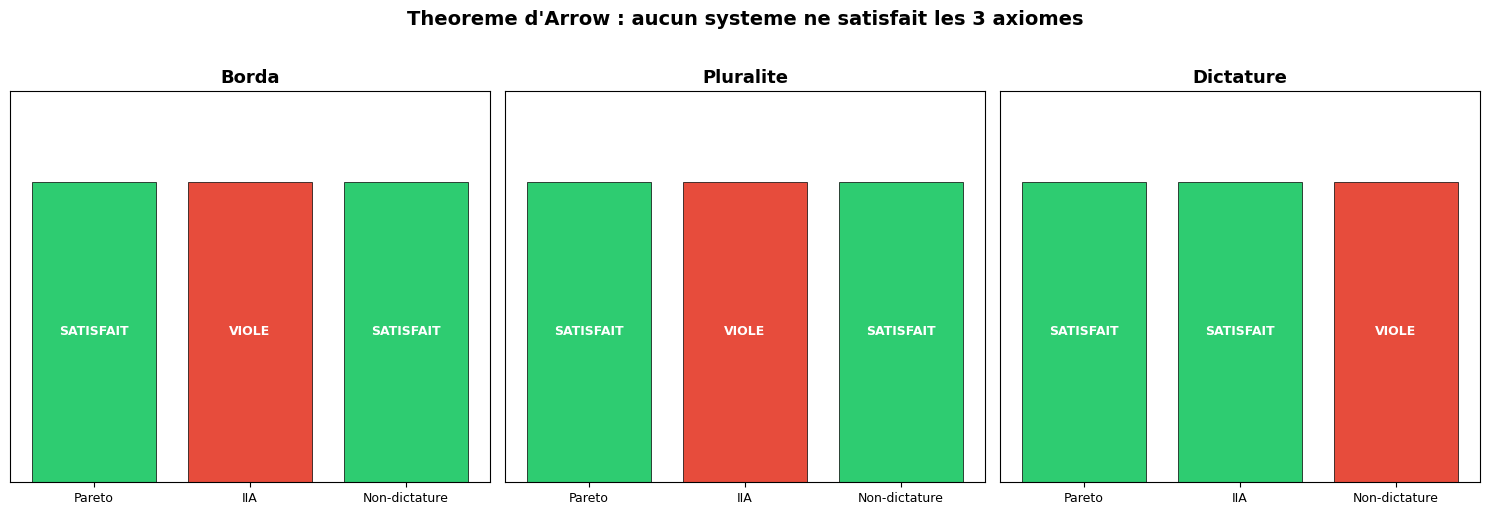

Synthese visuelle generee.


In [9]:
# 4. Visualisation : Synthese des axiomes

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

rules = ['Borda', 'Pluralite', 'Dictature']
axioms = ['Pareto', 'IIA', 'Non-dictature']

# Resultats tires des tests precedents
# 1 = satisfait (vert), 0 = viole (rouge)
results = {
    'Borda':     [1, 0, 1],  # Pareto OK, IIA viole, Non-dict OK
    'Pluralite': [1, 0, 1],  # Pareto OK, IIA viole, Non-dict OK
    'Dictature': [1, 1, 0],  # Pareto OK, IIA OK, Non-dict viole
}

colors_map = {1: '#2ecc71', 0: '#e74c3c'}

for idx, (rule_name, ax) in enumerate(zip(rules, axes)):
    values = results[rule_name]
    bars = ax.bar(axioms, [1, 1, 1], color=[colors_map[v] for v in values],
                  edgecolor='black', linewidth=0.5)

    for i, v in enumerate(values):
        label = "SATISFAIT" if v == 1 else "VIOLE"
        ax.text(i, 0.5, label, ha='center', va='center',
                fontweight='bold', fontsize=9, color='white')

    ax.set_ylim(0, 1.3)
    ax.set_title(rule_name, fontsize=13, fontweight='bold')
    ax.set_yticks([])
    ax.tick_params(axis='x', labelsize=9)

# Titre global
fig.suptitle("Theoreme d'Arrow : aucun systeme ne satisfait les 3 axiomes",
             fontsize=14, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

print("Synthese visuelle generee.")

---

## 5. Resume

### Mapping Preuve Lean <-> Simulation Python

| Etape de la preuve Lean | Theoreme Lean | Demonstration Python |
|--------------------------|---------------|----------------------|
| Axiome Pareto | `weak_pareto` (Framework.lean:31) | `check_weak_pareto()` sur 500 profils |
| Axiome IIA | `ind_of_irr_alts` (Framework.lean:36) | `check_iia()` sur 1000 paires de profils |
| Non-dictature | `non_dictatorial` (Arrow.lean:693) | `check_non_dictatorship()` sur 500 profils |
| Lemme Extremal | `extremal_lemma` (Arrow.lean:199) | Profils avec B en position extreme |
| Existence du Pivot | `pivot_exists` (Arrow.lean:279) | Sequence de basculement du bas vers le haut |
| Pivot = Dictateur partiel | `pivot_is_dictator_except_b` (Arrow.lean:408) | Concordance pivot/social sur paires sans B |
| Theoreme final | `arrow` (Arrow.lean:679) | Force brute exhaustive (216 profils) |
| Corollaire negatif | `no_perfect_swf` (Arrow.lean:697) | Aucune regle ne satisfait les 3 axiomes |

### Lecons principales

1. **Preuve formelle > Simulation** : la preuve Lean couvre une infinite de cas que la simulation ne peut pas atteindre
2. **IIA est l'axiome limitant** : les regles usuelles (Borda, Pluralite) violent toutes IIA
3. **Dictature = seul match Pareto + IIA** : la preuve d'Arrow montre que seule la dictature peut combiner ces deux axiomes
4. **La structure de la preuve** (extremal -> pivot -> dictateur partiel -> dictateur complet) est elegante et constructive

### Pour aller plus loin

- **Notebook 16b** : la preuve complete en Lean avec les definitions formelles
- **Notebook 16c** : simulations Python avancees (Condorcet, Sen, electeur median)
- **Notebook 16d** : approche SAT pour la verification des axiomes
- **Notebook 16e** : tour du code Lean `social_choice_lean`
- **Notebook 16f** : verification formelle avec Z3

---

**Navigation** : [<< 16b-Lean-SocialChoice](GameTheory-16b-Lean-SocialChoice.ipynb) | [16c-SocialChoice-Python >>](GameTheory-16c-SocialChoice-Python.ipynb) | [Index](README.md)

---

## Exercice 1 : Explorer le Lemme Extremal avec 4 alternatives

**Objectif** : Verifier que le lemme extremal s'applique aussi avec plus de 3 alternatives.

**Ce que vous devez implementer** :
- Modifier la fonction `generate_extremal_profiles` pour 4 alternatives
- Tester que l'alternative cible reste en position extreme dans le classement social
- Comparer les resultats avec 3 et 4 alternatives

In [10]:
# Exercice 1 : Lemme Extremal avec 4 alternatives
# ================================================

# TODO etudiant : adaptez generate_extremal_profiles pour 4 alternatives
# Indice : avec ['A', 'B', 'C', 'D'], la cible 'B' peut etre en premiere
# ou derniere position. Les 3 autres alternatives sont melangees entre elles.

alternatives_4 = ['A', 'B', 'C', 'D']

# TODO etudiant : generez 100 profils ou B est toujours en position extreme
# et comptez combien de fois B reste en position extreme dans le classement Borda.

# Indice : utilisez une boucle similaire au test systematique de la section 2.1
# mais avec alternatives_4 au lieu de alternatives_3.

# TODO etudiant : comparez les resultats avec 3 et 4 alternatives.
# Le lemme extremal s'applique-t-il aussi bien avec 4 alternatives ?

print("Exercice 1 : Lemme Extremal avec 4 alternatives")

Exercice 1 : Lemme Extremal avec 4 alternatives


---

## Exercice 2 : Construire un contre-exemple IIA pour Borda

**Objectif** : Trouver **explicitement** (pas par tirage aleatoire) deux profils qui montrent une violation de IIA par la methode de Borda.

**Ce que vous devez implementer** :
- Deux profils ou les preferences entre A et B sont identiques pour chaque electeur
- Mais le classement social de A vs B change
- Expliquer pourquoi cela viole IIA

In [11]:
# Exercice 2 : Contre-exemple IIA explicite pour Borda
# =====================================================

# TODO etudiant : construisez deux profils avec 3 electeurs et 3 alternatives
# ou les preferences relatives entre A et C sont identiques pour chaque electeur,
# mais le classement social de A vs C change.

# Indice : changez uniquement la position de B (l'alternative "non pertinente")
# dans les preferences d'un electeur.

# profil_1 = [
#     ['A', 'B', 'C'],  # Electeur 1 : A > C (inchange)
#     ['B', 'A', 'C'],  # Electeur 2 : A > C (inchange)
#     ['C', 'B', 'A'],  # Electeur 3 : C > A (inchange)
# ]
#
# profil_2 = [
#     ['A', 'B', 'C'],  # Electeur 1 : A > C (inchange)
#     ['A', 'B', 'C'],  # Electeur 2 : A > C (inchange, mais B monte)
#     ['C', 'B', 'A'],  # Electeur 3 : C > A (inchange)
# ]

# TODO etudiant : verifiez que dans chaque profil, chaque electeur a la
# meme preference relative entre A et C.

# TODO etudiant : appliquez borda_rule() aux deux profils et comparez
# la position relative de A et C.

# TODO etudiant : expliquez pourquoi cela constitue une violation de IIA.

print("Exercice 2 : Contre-exemple IIA pour Borda")

Exercice 2 : Contre-exemple IIA pour Borda


---

## Exercice 3 : Comparer la complexite de la force brute

**Objectif** : Calculer le nombre de profils possibles pour differentes configurations et comprendre pourquoi la force brute ne suffit pas.

**Ce que vous devez implementer** :
- Une fonction qui calcule le nombre de profils possibles
- Un tableau comparatif pour differentes tailles
- Estimer le temps necessaire pour une enumeration exhaustive

In [12]:
# Exercice 3 : Complexite de la force brute
# ==========================================

def count_profiles(n_voters, n_alternatives):
    """Calcule le nombre de profils possibles.

    Args:
        n_voters: nombre de votants
        n_alternatives: nombre d'alternatives

    Returns:
        int: nombre de profils possibles = (n_alternatives!) ^ n_voters
    """
    from math import factorial
    return factorial(n_alternatives) ** n_voters


print("Exercice 3 : Complexite de la force brute")

# Configurations a tester
configs = [
    (3, 3),
    (5, 3),
    (10, 4),
]

# TODO etudiant : ajoutez d'autres configurations
# (par exemple, 20 votants, 5 alternatives)

for n_v, n_a in configs:
    n_prof = count_profiles(n_v, n_a)
    print(f"Nombre de profils possibles pour "
          f"({n_v} votants, {n_a} alternatives) : {n_prof}")

    # Estimation du temps a 1 million de profils/seconde
    seconds = n_prof / 1_000_000
    if seconds > 3600:
        print(f"A 1 million de profils/seconde, il faudrait environ "
              f"{seconds / (3600 * 24 * 365):.1f} annees pour ({n_v}, {n_a})")
    elif seconds > 60:
        print(f"A 1 million de profils/seconde, il faudrait environ "
              f"{seconds / 60:.1f} minutes pour ({n_v}, {n_a})")
    else:
        print(f"A 1 million de profils/seconde, il faudrait environ "
              f"{seconds:.1f} secondes pour ({n_v}, {n_a})")

print("=> La force brute est impraticable pour des cas reels")

# TODO etudiant : calculez le nombre de SWF possibles
# (chaque SWF est une fonction de l'ensemble des profils vers l'ensemble
# des classements). Combien y a-t-il de SWF pour (3, 3) ?
# Indice : c'est (n_alternatives!) ^ (nombre de profils)

Exercice 3 : Complexite de la force brute
Nombre de profils possibles pour (3 votants, 3 alternatives) : 216
A 1 million de profils/seconde, il faudrait environ 0.0 secondes pour (3, 3)
Nombre de profils possibles pour (5 votants, 3 alternatives) : 7776
A 1 million de profils/seconde, il faudrait environ 0.0 secondes pour (5, 3)
Nombre de profils possibles pour (10 votants, 4 alternatives) : 63403380965376
A 1 million de profils/seconde, il faudrait environ 2.0 annees pour (10, 4)
=> La force brute est impraticable pour des cas reels
